In [1]:
%matplotlib inline
#import skmob
import pandas as pd
#import skmob.measures.individual as ind_measure
import torch
import gpytorch
from gpytorch.kernels import RQKernel as RQ, RBFKernel as SE, \
PeriodicKernel as PER, ScaleKernel, LinearKernel as LIN, MaternKernel as MAT, \
SpectralMixtureKernel as SMK, PiecewisePolynomialKernel as PPK, CylindricalKernel as CYL
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error
from gpytorch.constraints import Interval
import time

# Import intra-package scripts
import utils.helper_func as helper_func
import utils.GP as GP
import mobileDataToolkit.analysis as analysis
import mobileDataToolkit.preprocessing as preprocessing

In [2]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

## Reading Data

In [3]:
file_path = "C:\\Users\\stlp\\OneDrive - UW\\GPR\\Data\\all_obs_preprocessed.csv"

d1 = preprocessing.dp_MultiTrip(file_path, 8765765)
d1.chooseUser(d1.data.user_ID.unique()[9])

## Preprocessing Data: Adding "DateTime" column, subsetting by a timeframe

In [4]:
d1.add_DateTime()

d1.subsetByTime('01/18/2020 00:00', '02/07/2020 00:00')

data = d1.Multi_Trip_Preprocess()

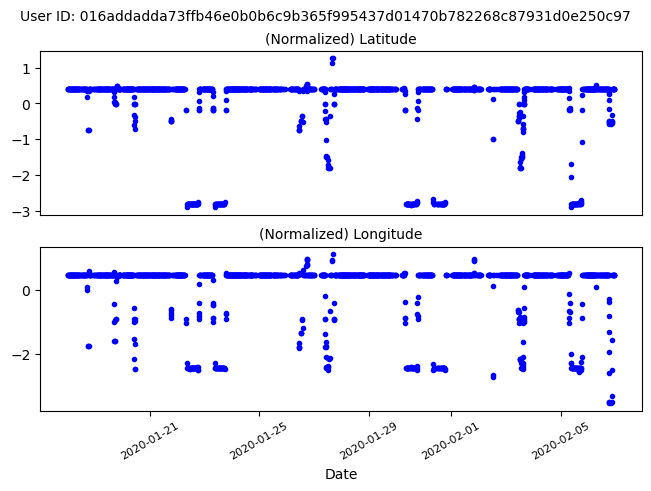

In [5]:
d1.mobVisualize(data)

## Train/Test Split

In [6]:
d1.Multi_Trip_TrainTestSplit('2020-02-01 00:00', '2020-02-07 00:00')

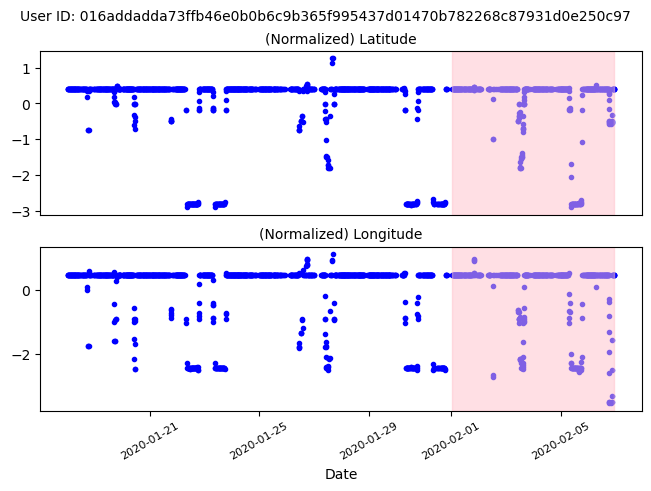

In [7]:
d1.mobVisualize(data)

In [8]:
d1.train

,unix_start_t_min,date,lat,long
0,0.0,2020-01-18 00:10:17,47.903023,-122.225647
1,10.0,2020-01-18 00:21:01,47.903023,-122.225647
2,31.0,2020-01-18 00:41:57,47.903023,-122.225647
3,42.0,2020-01-18 00:52:31,47.903023,-122.225647
4,55.0,2020-01-18 01:05:41,47.903023,-122.225647
...,...,...,...,...
1208,19816.0,2020-01-31 18:26:40,47.613653,-122.335547
1209,19861.0,2020-01-31 19:11:54,47.903023,-122.225647
1210,19895.0,2020-01-31 19:46:08,47.903023,-122.225647
1211,19906.0,2020-01-31 19:56:33,47.903023,-122.225647


## Temporal Occupancy

In [9]:
full_TO = analysis.tempOcp(d1.train, bin_len=5)
full_TO

0.3031062124248497

### Short Gap Simulation Design
* **Assumption**: MCAR (will remove points randomly)
* Use trip data only (include trips from the past)
* Divide each trip into X-min intervals
    + Sensitivity Analysis
        - Try 1, 5, 10, 15, 30-min intervals
* Introduce sparsity at 10% intervals
    + i.e., first remove 10% of the X-min intervals, then 20%, etc.
        - Repeat process 10 times at each q to allow for different portions of the data to be removed
 

In [38]:
tau = 5 # bin length
sparsity = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for i in range(10): # Cross-validation
    ### code below
    
    ###
    return  # output?

SyntaxError: 'return' outside function (1571725188.py, line 8)